In [108]:

%load_ext autoreload
%autoreload 2
from mGST.low_level_jit import cost_function_jax_mps, objf, cost_function_jax
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_result_and_configuration, create_4q_gst_config, get_compressed_perturbed_rep_from_mgst, get_mgst_tensors_from_psd_representation, get_compressed_rep_from_mgst_output
from mGST.trust_region import run_riemannian_optimization
from mGST.typing import TrustRegionOptions, OperatorSchedule
from mGST.visualization import plot_alternating_optimization
from iqm.benchmarks.compressive_gst.compressive_gst import CompressiveGST

import jax.numpy as jnp

from iqm.qiskit_iqm import IQMProvider

import os
os.environ[
    "IQM_TOKEN"
] = "UWcEU3ZP7mxzs7XBs4Lit7sht39u9wmoX/cQ6p3HsiMBmb9y++B244T70dk7QacX"

iqm_server_url = "https://cocos.resonance.meetiqm.com/garnet"
provider = IQMProvider(iqm_server_url)
backend = provider.get_backend()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/iqm/iqm_client/iqm_client.py:135: UserWarning: Your IQM Client version 20.17 was built for a different version of IQM Server. You might encounter issues. For the best experience, consider using a version of IQM Client that satisfies 33.0.3 <= iqm-client < 33.0.3.
  warnings.warn(version_incompatibility_msg)


- Employ a reasonable number of sequences. Raphael suggested to wait 1 hour, which under the assumption of 500 shots per circuit with 400 micro seconds per circuit, we would be able to run ~18,000 circuits.
- Compute how many circuits we would need to cover parameters for all (Kraus, POVM, and state) for a given rank and decide the rank based on that. Include most conservative gauge degrees of freedom?

* $k$ = num of gates
* $m$ = num of povms
* $d$ = Hilbert space dimension
* $r_k$ = Kraus rank
* $r_E $= POVM rank
* $r_\rho$ = State rank

$\left[k(d^2(2 r_k - 1) - r_k^2)\right] + \left[d(2m r_E - d) - Mr_E^2\right] + \left[2dr_\rho - r_\rho^2\right] - \mathrm{MPS}_{Gauge}$

# Initial tests

* number of parameters calculation
* verifying IQM client timeouts
* create 4Q config
* reproduce overflow error when sampling depth 20

In [2]:
def calculate_num_parameters(
    num_gates: int,
    num_povm: int,
    dim: int,
    kraus_rank: int,
    povm_rank: int,
    state_rank: int,
    global_gauge: int = None
) -> int:
    """Calculate the number of parameters for GST.
    
    Args:
        num_gates: Number of gates in the Kraus tensor
        num_povm: Number of POVMs
        dim: Hilbert space dimension
        kraus_rank: Kraus rank
        povm_rank: POVM rank
        state_rank: State rank
        global_gauge: Global gauge degrees of freedom along the bond dimension(default: dim^2)
    
    Returns:
        Total number of parameters substracting gauge degrees of freedom.
    """
    # Kraus
    kraus_stiefel_dim =  dim**2 * (2 * kraus_rank - 1)
    kraus_gauge = kraus_rank**2
    kraus_term = num_gates * (kraus_stiefel_dim - kraus_gauge) # times num_gates for every kraus
    
    # POVM
    povm_stiefel_dim = dim * (2 * num_povm * povm_rank - dim)
    povm_gauge = num_povm * povm_rank**2
    povm_term = povm_stiefel_dim - povm_gauge
    
    # State
    state_stiefel_dim = 2 * dim * state_rank
    state_gauge = state_rank**2
    state_term = state_stiefel_dim - state_gauge 
    
    # Global Gauge along bond dimensions
    if global_gauge is not None:
        global_gauge = dim**2
        
    return kraus_term + povm_term + state_term - global_gauge

In [83]:
num_qubits = 4
dim = 2**num_qubits

kraus_rank = 1 # coherent (unitary) errors
state_rank = 1
povm_rank = 1

num_gates = 9
num_povm = dim

global_gauge = dim**2 # I think it should be multiplied by the depth of circuit.

total_params = calculate_num_parameters(
    num_gates=num_gates,
    num_povm=num_povm,
    dim=dim,
    kraus_rank=kraus_rank,
    povm_rank=povm_rank,
    state_rank=state_rank,
    global_gauge=global_gauge
)
print(f"Total number of parameters: {total_params}")

print("We will use  >= 3x this number of parameters for the number of sequences")
print(f"Number of sequences: {3*total_params}")

Total number of parameters: 2310
We will use  >= 3x this number of parameters for the number of sequences
Number of sequences: 6930


In [4]:
60 * 60

3600

In [5]:
# Changed the default timeout in iqm_client.py to 9000 seconds
from iqm.iqm_client.iqm_client import DEFAULT_TIMEOUT_SECONDS, REQUESTS_TIMEOUT
print(f'Request time out: {REQUESTS_TIMEOUT / 60} minutes') # in minutes
print(f'Default timeout: {DEFAULT_TIMEOUT_SECONDS / 60 / 60} hours') # in hours, 

Request time out: 60.0 minutes
Default timeout: 2.5 hours


In [10]:
# max_gates_per_batch = 10000 # limit for real backend - computed using the fact that we are allowed 500 circuits per job and each circuit has at most 22 gates
max_circuits_per_batch = 100 # limit for real backend. Update: I had to change this because it was throwing errors.
num_sequences = 10000 # >= 3 x total_params
shots = 500

In [ ]:
config_4q = create_4q_gst_config(kraus_rank=kraus_rank, num_gate_sequences=num_sequences, shots=shots, max_gates_per_batch=None, max_circuits_per_batch=max_circuits_per_batch, seq_len_list=[1, 10, 19])
benchmark = CompressiveGST(backend, config_4q)
config_4q.seq_len_list

[1, 10, 19]

In [20]:
config_4q.gate_set[0].draw(), config_4q.max_circuits_per_batch

(     ┌──────────┐
 q_0: ┤ R(π/2,0) ├
      └──────────┘
 q_1: ────────────
                  
 q_2: ────────────
                  
 q_3: ────────────
                  ,
 100)

In [29]:
# This test was done here to replicate the overflow error I was obtaining when generating too deep sequences.
import random
random.sample(range(9**20), 500)

OverflowError: Python int too large to convert to C ssize_t

# Run result (do not re-run)

In [22]:
result = benchmark.run()

2026-02-02 14:04:45,424 - iqm.benchmarks.logging_config - INFO - Generating 10000 random GST circuits
2026-02-02 14:04:56,746 - iqm.benchmarks.logging_config - INFO - Will transpile all 10000 circuits according to fixed physical layout
2026-02-02 14:05:06,542 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQM Backend with optimization level 0, sabre routing method all circuits
2026-02-02 14:06:21,125 - iqm.benchmarks.logging_config - INFO - Submitting batch with 10000 circuits corresponding to qubits [0, 1, 3, 4]
2026-02-02 14:06:21,128 - iqm.benchmarks.logging_config - INFO - max_circuits_per_batch restriction: submitting subbatch #1 with 100 circuits corresponding to qubits [0, 1, 3, 4]
/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/iqm/qiskit_iqm/iqm_provider.py:170: UserWarning: Unknown backend option(s): {'calibration_set_id'}
  warnings.warn(f'Unknown backend option(s): {unknown_options}')
2026-02-02 14:06:22,344 - iqm.benchmarks.l

In [23]:
benchmark.runs

[BenchmarkRunResult(dataset=<xarray.Dataset> Size: 3MB
 Dimensions:                   ([0, 1, 3, 4]_state_0: 5,
                                [0, 1, 3, 4]_state_1: 6,
                                [0, 1, 3, 4]_state_2: 5,
                                [0, 1, 3, 4]_state_3: 5,
                                [0, 1, 3, 4]_state_4: 6,
                                [0, 1, 3, 4]_state_5: 5,
                                ...
                                [0, 1, 3, 4]_state_9994: 16,
                                [0, 1, 3, 4]_state_9995: 10,
                                [0, 1, 3, 4]_state_9996: 11,
                                [0, 1, 3, 4]_state_9997: 11,
                                [0, 1, 3, 4]_state_9998: 15,
                                [0, 1, 3, 4]_state_9999: 14)
 Coordinates: (12/10000)
   * [0, 1, 3, 4]_state_0      ([0, 1, 3, 4]_state_0) <U4 80B '0000' ... '1000'
   * [0, 1, 3, 4]_state_1      ([0, 1, 3, 4]_state_1) <U4 96B '0000' ... '1000'
   * [0, 1, 3, 4

# Save benchmark result

In [26]:
import pickle

with open("run_result_4Q_10000seq_500shots.pkl", "wb") as f:
    pickle.dump(result, f)

# Obtain intialized tensors

In [30]:
kraus_tensor_mgst, kraus_mgst, povm_mgst, state_mgst, prob_matrix, indices_list = get_full_mgst_parameters_from_result_and_configuration(result=result, configuration=config_4q, only_jax_variables=True, seed=42
)

INFO:2026-02-02 15:54:31,837:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-02-02 15:54:31,837 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-02-02 15:54:31,857:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

In [53]:
kraus_tensor_mgst.shape, povm_mgst.shape, state_mgst.shape, prob_matrix.shape, len(indices_list), kraus_mgst.shape

((9, 1, 16, 16), (16, 256), (256,), (16, 10000), 10000, (9, 256, 256))

In [51]:
# the state should actually be pure:
jnp.linalg.matrix_rank(state_mgst.reshape((dim, dim)))

Array(1, dtype=int64)

In [52]:
# Each of the POVM elements should also be rank-1
povm_reshaped = povm_mgst.reshape((num_povm, dim, dim))
jnp.linalg.matrix_rank(povm_reshaped)

Array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

## Save initial tensors

In [38]:
# Save
import numpy as np
np.savez(
    "gst_tensors_4q_10000seq_500shots.npz",
    kraus_tensor_mgst=np.array(kraus_tensor_mgst),
    povm_mgst=np.array(povm_mgst),
    state_mgst=np.array(state_mgst),
    prob_matrix=np.array(prob_matrix),
    indices_list=np.array(indices_list, dtype=object)  # for list of arrays
)

# Perturbed tensors and get PSD

In [ ]:
# Kraus is already perturbed
kraus_tensor_init_jax = jnp.array(kraus_tensor_mgst)
povm_psd_init_jax, state_psd_init_jax = get_compressed_perturbed_rep_from_mgst(povm_mgst, state_mgst)

init_operators_jax = {
    "kraus_tensor_init": kraus_tensor_init_jax,
    "povm_psd_init": povm_psd_init_jax,
    "state_psd_init": state_psd_init_jax,
}

cost_fn_kwargs = {
    "indices_list": indices_list,
    "prob_matrix": prob_matrix,
    "jit": True,
}

initial_cost_value = cost_function_jax_mps(kraus_tensor_init_jax, povm_psd_init_jax, state_psd_init_jax, **cost_fn_kwargs)
print("Initial cost value:", initial_cost_value)

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/low_level_jit.py:588: UserWarning: Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.
  warnings.warn("Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.")


at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 704 the new count changed to: 5
at iteration 1317 the new count changed to: 6
at iteration 1930 the new count changed to: 7
at iteration 2544 the new count changed to: 8
at iteration 3158 the new count changed to: 9
at iteration 3772 the new count changed to: 10
at iteration 4386 the new count changed to: 11
at iteration 5000 the new count changed to: 12
at iteration 5555 the new count changed to: 13
at iteration 6110 the new count changed to: 14
at iteration 6665 the new count changed to: 15
at iteration 7220 the new count changed to: 16
at iteration 7776 the new count changed to: 17
at iteration 8332 the new count changed to: 18
at iteration 8888 the new count changed to: 19
at iteration 9444 the new count changed to: 20
Initial cost value: 0.0008497723475486373


In [ ]:
[(name, op.shape) for name, op in init_operators_jax.items()] # this means we are using max povm and state ranks (dim )

[('kraus_tensor_init', (9, 1, 16, 16)),
 ('povm_psd_init', (16, 16, 16)),
 ('state_psd_init', (16, 16))]

## time the cost function for estimation

In [41]:
timing_4q_non_jit_coherent = %timeit -o cost_function_jax_mps(kraus_tensor_init_jax, povm_psd_init_jax, state_psd_init_jax, indices_list=indices_list, prob_matrix=prob_matrix, jit=False)

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/low_level_jit.py:588: UserWarning: Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.
  warnings.warn("Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.")


13.7 s ± 75.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [40]:
timing_4q_jit_coherent = %timeit -o cost_function_jax_mps(kraus_tensor_init_jax, povm_psd_init_jax, state_psd_init_jax, **cost_fn_kwargs)

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/low_level_jit.py:588: UserWarning: Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.
  warnings.warn("Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.")


817 ms ± 4.16 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Optimization

In [44]:
num_iterations_all_tr = 2
tr_schedule_verbose = OperatorSchedule.default(num_iterations_all_tr, TrustRegionOptions(num_iterations=10, verbose=True, verbose_cg=True, num_iterations_cg=5))

tr_schedule_state = OperatorSchedule.default(num_iterations_all_tr, TrustRegionOptions(num_iterations=10, verbose=True, verbose_cg=True, num_iterations_cg=5, tol_grad=1e-8))

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_state
}

In [45]:
optimized_operators_all_tr, cost_fn_history_all_tr = run_riemannian_optimization(
    **init_operators_jax,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations_all_tr,
    optimization_schedule=optimization_schedule_all_tr,
    verbose=True,
    save_intermediate_cost_values=True, # To plot all intermediate values of each operator
)

🔰 Starting Riemannian Optimization 🔰 
 with optimization schedule: 
kraus: Schedule:
  [0-1]: TrustRegionOptions
povm: Schedule:
  [0-1]: TrustRegionOptions
state: Schedule:
  [0-1]: TrustRegionOptions
TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 8.497723e-04. |r∇f(x)|: 3.856279e-04. Radius: 1.00e-01
TCG finished after: 1/5 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 8.173345e-04. |r∇f(x)|: 2.670077e-04. Radius: 2.00e-01
TCG finished after: 1/5 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 2. f(x): 7.855616e-04. |r∇f(x)|: 1.024116e-04. Radius: 4.00e-01
TCG finished after: 5/5 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 3. f(x): 7.740607e-04. |r∇f(x)|: 1.002724e-05. Radius: 4.00e-01
TCG finished after: 5/5 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iterat

# Plotting

In [46]:
data_operator_map = [
    ("povm", 10), ("kraus", 10), ("state", 10), ("povm", 10), ("kraus", 10), ("state", 10),
] # assume the first data point is the un-optimized one
# length of the sequences defined by data operator map
length_of_sequences = sum([length for _, length in data_operator_map])

print("Length of sequences:", length_of_sequences)
print(len(cost_fn_history_all_tr))

Length of sequences: 60
61


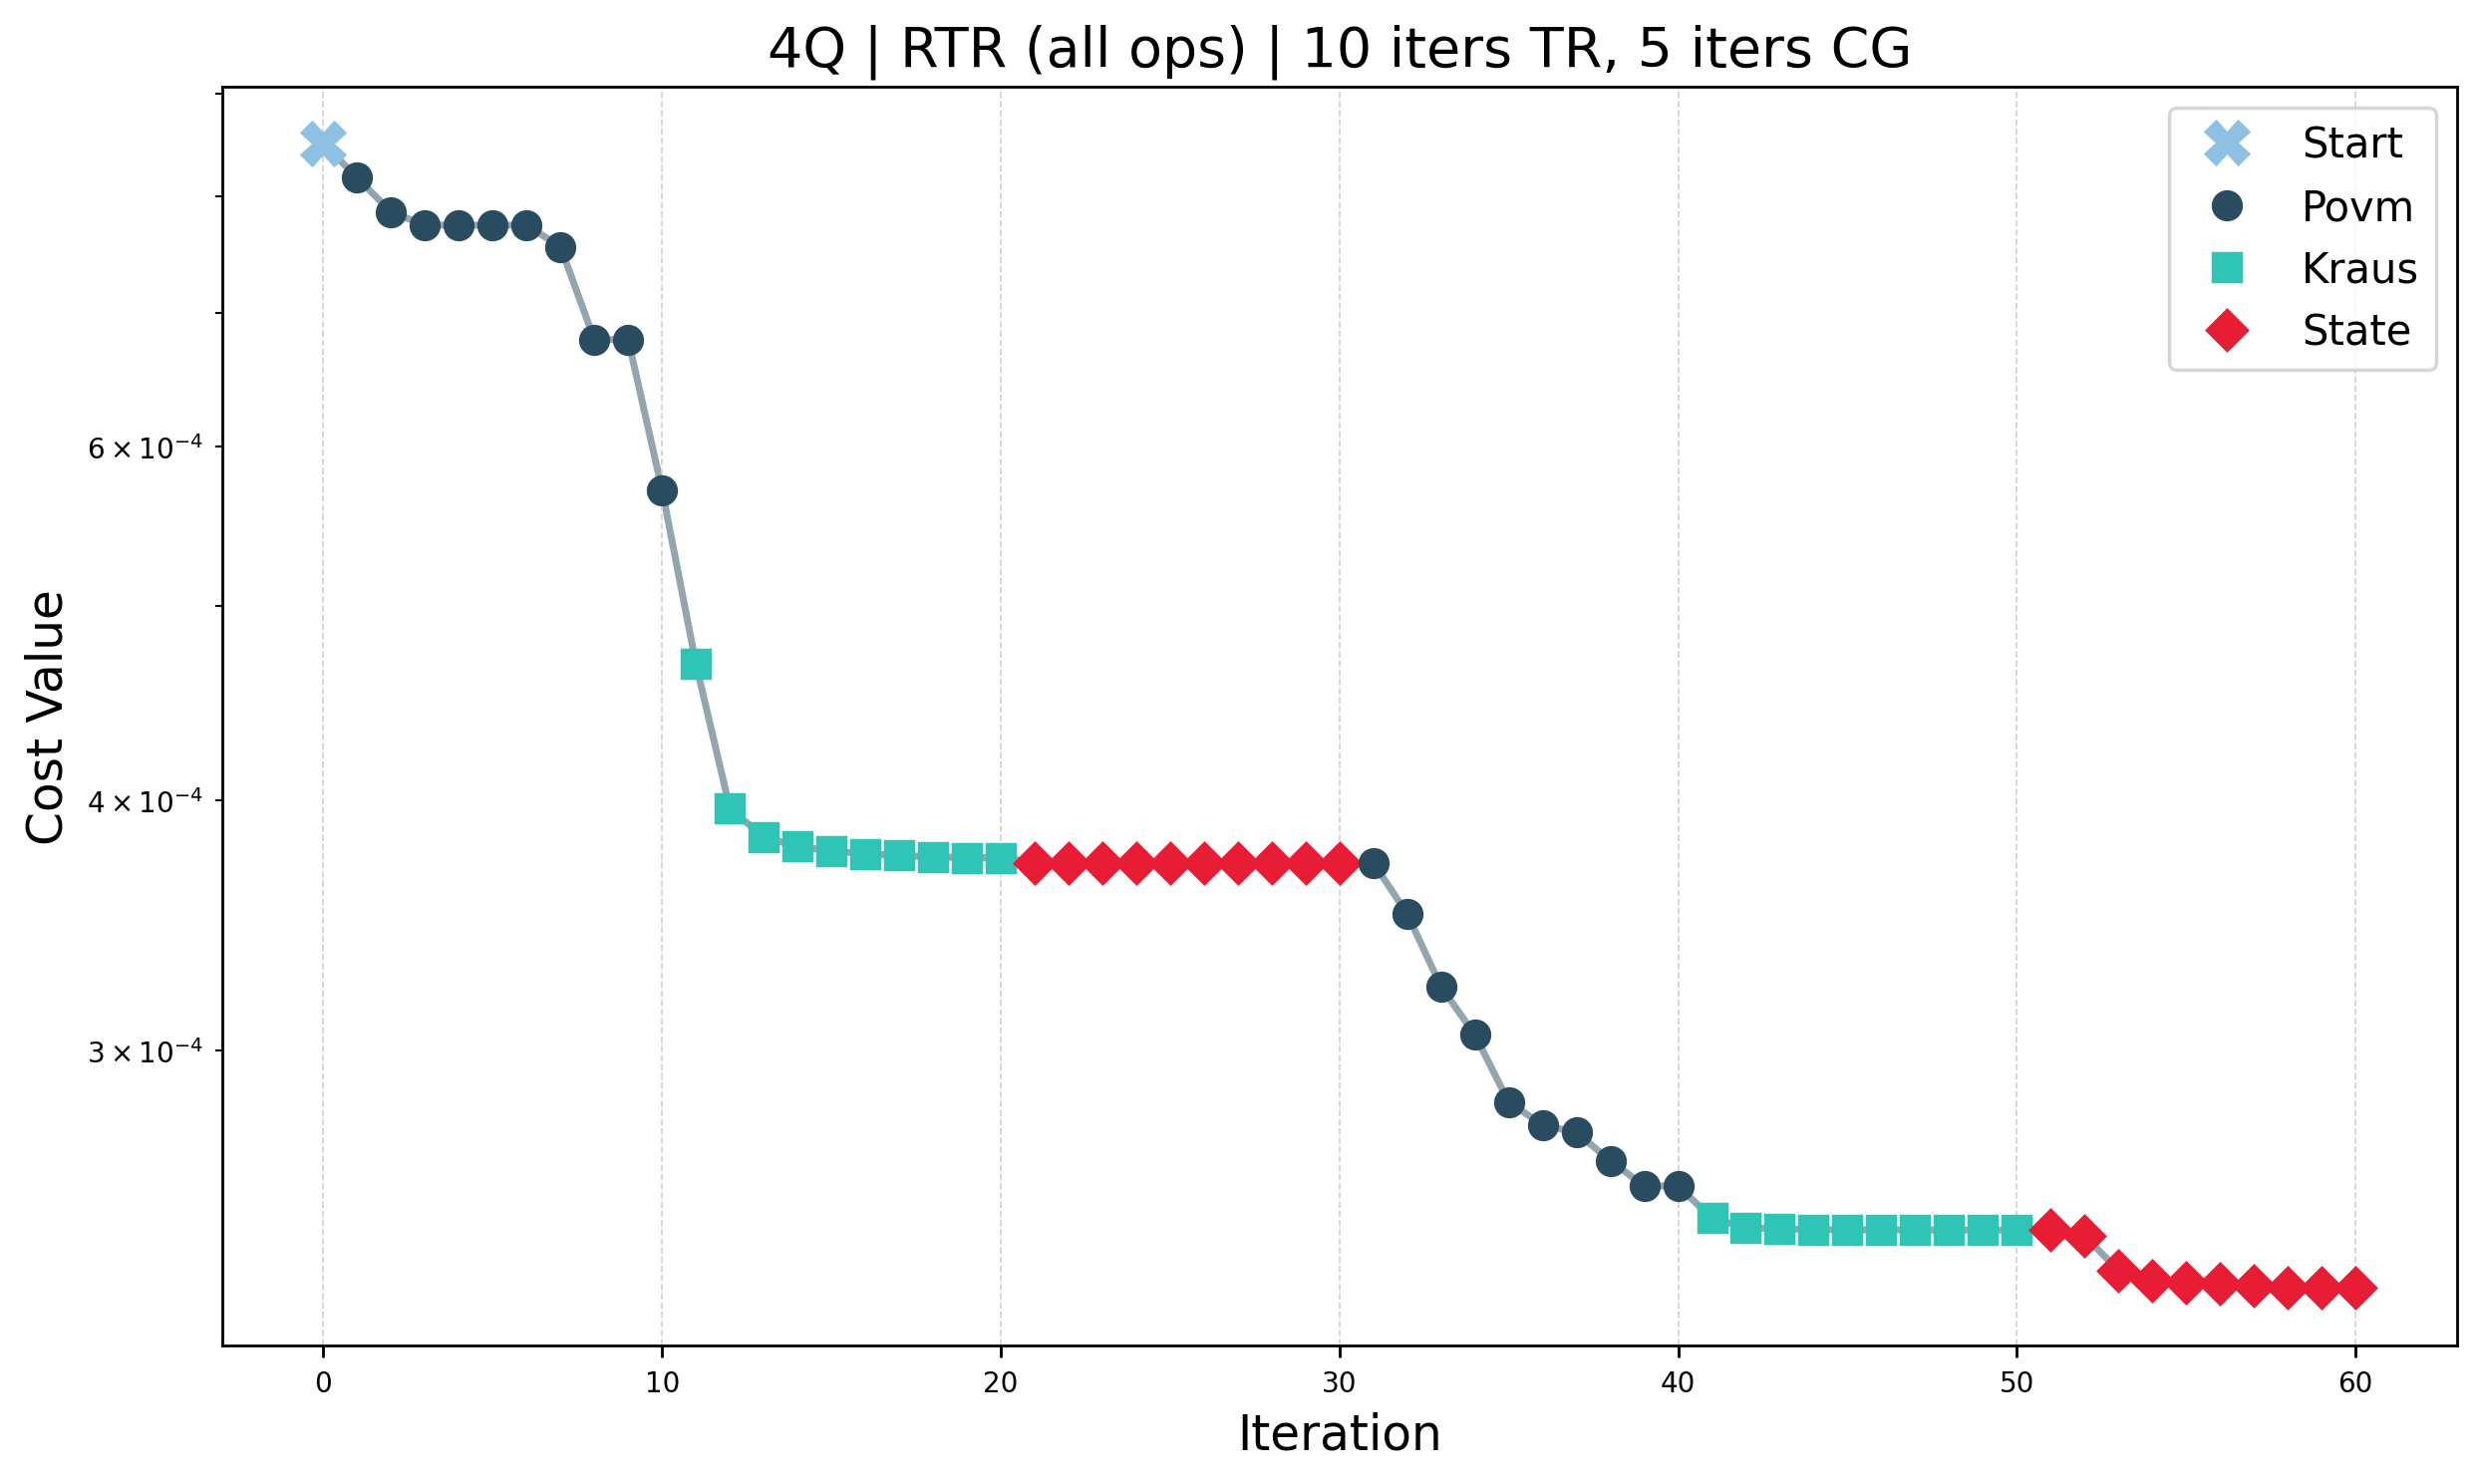

In [ ]:
plot_alternating_optimization(
    cost_array=cost_fn_history_all_tr,
    data_operator_map=data_operator_map,
    title="4Q | RTR (all ops) | 10 iters TR, 5 iters CG | time: 215min 11.2s"
)

# Save the optimized operators and the cost function

In [48]:
optimized_operators_all_tr.keys()

dict_keys(['kraus', 'povm', 'state'])

In [49]:
np.savez(
    "optimization_results_4q_10000seq_500shots_all_tr.npz",
    kraus_tensor=np.array(optimized_operators_all_tr["kraus"]),
    povm_psd=np.array(optimized_operators_all_tr["povm"]),
    state_psd=np.array(optimized_operators_all_tr["state"]),
    cost_fn_history_all_tr=np.array(cost_fn_history_all_tr),
)

# Gauge optimization

In [50]:
from mGST.reporting.reporting import gauge_opt
from mGST.compatibility import arrays_to_pygsti_model

In [58]:
# The target model is the mgst tensors obtained in the beginning without perturbation
target_ops = {
    "X": kraus_mgst,
    "E": povm_mgst,
    "rho": state_mgst
}


In [59]:
target_model_pygsti = arrays_to_pygsti_model(**target_ops, basis="std")

In [64]:
gauge_weights = result.dataset.attrs["gauge_weights"]
gauge_weights

{'G0': 1,
 'G1': 1,
 'G2': 1,
 'G3': 1,
 'G4': 1,
 'G5': 1,
 'G6': 1,
 'G7': 1,
 'G8': 1,
 'spam': 0.1}

In [70]:
kraus_tensor_opt = optimized_operators_all_tr["kraus"]
povm_psd_opt = optimized_operators_all_tr["povm"]
state_psd_opt = optimized_operators_all_tr["state"]

[op.shape for op in optimized_operators_all_tr.values()]

[(9, 1, 16, 16), (16, 16, 16), (16, 16)]

In [72]:
# Need to obtain the MGST arrays from the optimized operators
optimized_ops_mgst = get_mgst_tensors_from_psd_representation(kraus_tensor=kraus_tensor_opt, povm_psd=povm_psd_opt, state_psd=state_psd_opt)
[(key, op.shape) for key, op in optimized_ops_mgst.items()]

[('kraus', (9, 256, 256)), ('povm', (16, 256)), ('state', (256,))]

In [73]:
kraus_mgst_gauge_opt, povm_mgst_gauge_opt, state_mgst_gauge_opt = gauge_opt(X=optimized_ops_mgst["kraus"], E=optimized_ops_mgst["povm"], rho=optimized_ops_mgst["state"], target_mdl=target_model_pygsti, weights=gauge_weights)

### Note:
it took `11 mins 17.4 s` to optimize the Gauge for this Gate Set!

In [74]:
kraus_mgst_gauge_opt.shape, povm_mgst_gauge_opt.shape, state_mgst_gauge_opt.shape

((9, 256, 256), (16, 256), (256,))

## Rank before vs after Gauge optimization

### Before gauge optimization

In [90]:
# Need to use the MGST representation to compute the rank (I guess I could do it direclty from PSD but not sure how)

povm_opt_mgst = optimized_ops_mgst["povm"]
state_opt_mgst = optimized_ops_mgst["state"]

rank_state_opt = jnp.linalg.matrix_rank(state_opt_mgst.reshape((dim, dim)))
rank_povm_opt = jnp.linalg.matrix_rank(povm_opt_mgst.reshape((num_povm, dim, dim)))

print("Optimized Model ranks before gauge optimization:")
print(f"State rank: {rank_state_opt}")
print(f"POVM rank: {rank_povm_opt}")

Optimized Model ranks before gauge optimization:
State rank: 16
POVM rank: [16 16 16 16 16 16 16 16 16 16 16 16 16 16 15 15]


### After Gauge optimization

In [78]:
# what are their ranks?
rank_state_opt_gauge = jnp.linalg.matrix_rank(state_mgst_gauge_opt.reshape((dim, dim)))
rank_state_opt_gauge

Array(16, dtype=int64)

In [79]:
# povm ranks
rank_povm_opt_gauge = jnp.linalg.matrix_rank(povm_mgst_gauge_opt.reshape((num_povm, dim, dim)))
rank_povm_opt_gauge

Array([16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 15, 15],      dtype=int64)

In [80]:
# Rank kraus. Currently kraus is of dimension (num_gates, dim_out x dim_out*, dim_in x dim_in*)
# To obtain the rank we need to reshape it to be a Choi matrix, i.e. (num_gates,  dim_in x dim_out, dim_in* x dim_out*)
from mGST.utility_functions_comparisons import superop2choi
kraus_mgst_gauge_opt_choi = superop2choi(kraus_mgst_gauge_opt)
rank_kraus_opt_gauge = jnp.linalg.matrix_rank(kraus_mgst_gauge_opt_choi)
rank_kraus_opt_gauge

Array([1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

## Save gauge optimized operators

In [76]:
np.savez(
    "gauge_optimized_MGST_operators_4q_10000seq_500shots.npz",
    kraus_tensor_mgst=kraus_mgst_gauge_opt,
    povm_mgst=povm_mgst_gauge_opt,
    state_mgst=state_mgst_gauge_opt,
)

# Tests on Gauge optimized tensors

In [ ]:
print("Original Model ranks:")
print("Kraus rank:", kraus_rank)
print("POVM rank:", povm_rank)
print("State rank:", state_rank)

Original Model ranks:
Kraus rank: 1
POVM rank: 1
State rank: 1


**Reminder**: However, when we perturbed the initial state and POVM we used the `mGST` functions which return the PSD operators using Cholesky, which does not truncate the rank. So both state and povm have max rank := `dim`.

In [86]:
# I have to obtain their PSD representations
kraus_tensor_gauge_opt, povm_psd_gauge_opt, state_psd_gauge_opt = get_compressed_rep_from_mgst_output(kraus_mgst=kraus_mgst_gauge_opt, povm_mgst=povm_mgst_gauge_opt, state_mgst=state_mgst_gauge_opt, kraus_rank=kraus_rank, povm_rank=dim, state_rank=dim) # max rank for povm and state (see above discussion)
gauge_opt_psd_operators = {
    "kraus_tensor": kraus_tensor_gauge_opt,
    "povm_psd": povm_psd_gauge_opt,
    "state_psd": state_psd_gauge_opt,
}

In [88]:
# Checking the cost function is the same as for the optimized operators without gauge optimization
cost_value_gauge_opt = cost_function_jax_mps(**gauge_opt_psd_operators, **cost_fn_kwargs)
cost_value_opt = cost_function_jax_mps(kraus_tensor=kraus_tensor_opt, povm_psd=povm_psd_opt, state_psd=state_psd_opt, **cost_fn_kwargs)

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/low_level_jit.py:588: UserWarning: Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.
  warnings.warn("Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.")


In [99]:
print("Are the costs the same?", jnp.allclose(cost_value_gauge_opt, cost_value_opt))
print("cost:", cost_value_gauge_opt, cost_value_opt)

Are the costs the same? True
cost: 0.00022841685024934687 0.0002284168502493495


In [109]:
cost_fn_mgst_init_jax = cost_function_jax(kraus_contracted=kraus_mgst, povm_matrix=povm_mgst, state_vector=state_mgst, indices_list=indices_list, prob_matrix=prob_matrix)
cost_fn_mgst_init_jax

Array(0.00084977, dtype=float64)

In [110]:
J_test = result.dataset.attrs["J"]
J_test.shape

(10000, 19)

In [ ]:
# Check cost function value using objf
# ANSWER: I was dividing everything again by m and n_povm inside the objf function (ERROR FROM MERGE)
cost_fn_mgst_init = objf(X=np.array(kraus_mgst), E=np.array(povm_mgst), rho=np.array(state_mgst), y=np.array(prob_matrix), J=indices_list)
cost_fn_mgst_init

5.31107717217897e-09

In [105]:
# the one from our cost function
cost_fn_history_all_tr[0]

Array(0.00084977, dtype=float64)

In [ ]:
# Is this same same as if we used the mGST cost function
cost_fn_mgst_gauge_opt = objf(X=kraus_mgst_gauge_opt, E=povm_mgst_gauge_opt, rho=state_mgst_gauge_opt, y=prob_matrix, J=indices_list)
cost_fn_mgst_gauge_opt

1.4276053140584072e-09

# Report

In [98]:
from mGST.reporting.reporting import quick_report

In [96]:
qubit_layout_str = str(config_4q.qubit_layouts[0])
qubit_layout_str

'[0, 1, 3, 4]'

In [97]:
gate_labels = result.dataset.attrs["gate_labels"][qubit_layout_str]
gate_labels

{0: 'Rx(pi/2)',
 1: 'Rx(pi/2)',
 2: 'Rx(pi/2)',
 3: 'Rx(pi/2)',
 4: 'Ry(pi/2)',
 5: 'Ry(pi/2)',
 6: 'Ry(pi/2)',
 7: 'Ry(pi/2)',
 8: 'CZ-CZ'}

In [ ]:
data_frame_gate, date_frame_rest = quick_report(
    X = kraus_mgst_gauge_opt,
    E = povm_mgst_gauge_opt,
    rho=state_mgst_gauge_opt,
    J=prob_matrix,
    indices_list=indices_list,
    target_mdl=target_model_pygsti,
    gate_labels=gate_labels
)